ML_LAB_TASK_5

IN_LAB

TASK-1.1

In [ ]:
import warnings

In [ ]:
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [ ]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [ ]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)


In [ ]:
X_pima = pima_df[pima_cols[:-1]]

In [ ]:
y_pima = pima_df['Outcome']

In [ ]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

In [ ]:
print("Pima Classification Training Set Shape:", X_train_c.shape)

Pima Classification Training Set Shape: (614, 8)


In [ ]:
print("Pima Classification Test Set Shape:", X_test_c.shape)

Pima Classification Test Set Shape: (154, 8)


TASK- 1.2

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
tree_clf.fit(X_train_c, y_train_c)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
clf_preds = tree_clf.predict(X_test_c)

In [ ]:
print(f"Decision Tree Classifier Test Accuracy: {accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n")

Decision Tree Classifier Test Accuracy: 79.87%



In [ ]:
print("--- Classification Report ---")

--- Classification Report ---


In [ ]:
print(classification_report(y_test_c, clf_preds, target_names=['No Diabetes (0)', 'Diabetes (1)']))

                 precision    recall  f1-score   support

No Diabetes (0)       0.82      0.88      0.85       100
   Diabetes (1)       0.74      0.65      0.69        54

       accuracy                           0.80       154
      macro avg       0.78      0.76      0.77       154
   weighted avg       0.80      0.80      0.80       154



TASK - 1.3

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from sklearn.tree import plot_tree

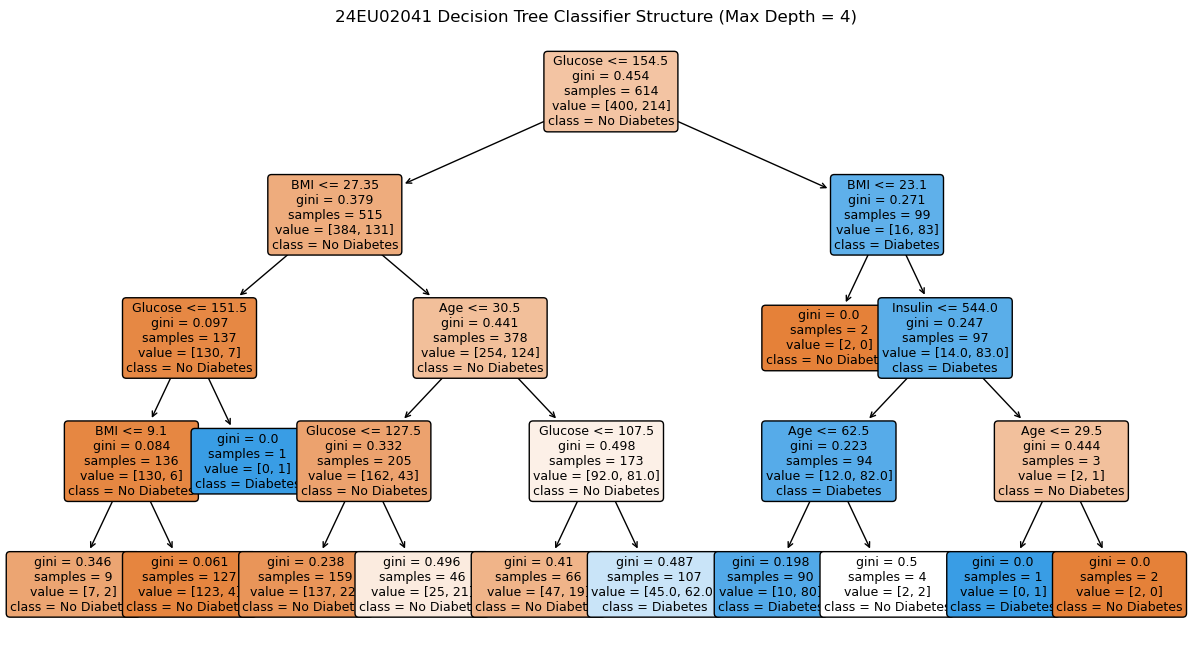

In [ ]:
plt.figure(figsize=(15, 8))
plot_tree(
    tree_clf,
    feature_names=pima_cols[:-1],
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("24EU02041 Decision Tree Classifier Structure (Max Depth = 4)")
plt.show()

TASK - 1.4

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

In [ ]:
boston_df = pd.read_csv(boston_url)

In [ ]:
boston_features = [col for col in boston_df.columns if col != 'medv']

In [ ]:
X_boston = boston_df[boston_features]

In [ ]:
y_boston = boston_df['medv']

In [ ]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_boston, y_boston, test_size=0.20, random_state=42)

In [ ]:
scaler_r = StandardScaler()

In [ ]:
X_train_r_scaled = scaler_r.fit_transform(X_train_r)

In [ ]:
X_test_r_scaled = scaler_r.transform(X_test_r)

In [ ]:
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
tree_reg.fit(X_train_r_scaled, y_train_r)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
print("Decision Tree Regressor trained successfully. Max Depth set to 5.")

Decision Tree Regressor trained successfully. Max Depth set to 5.


TASK - 1.5

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
import numpy as np

In [ ]:
reg_preds = tree_reg.predict(X_test_r_scaled)

In [ ]:
mse_val = mean_squared_error(y_test_r, reg_preds)

In [ ]:
rmse_val = np.sqrt(mse_val)

In [ ]:
r2_val = r2_score(y_test_r, reg_preds)

In [ ]:
print(f"Mean Squared Error (MSE): {mse_val:.4f}")

Mean Squared Error (MSE): 8.5539


In [ ]:
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f} ($1000s)")

Root Mean Squared Error (RMSE): 2.9247 ($1000s)


In [ ]:
print(f"R2 Coefficient of Determination: {r2_val:.4f}\n")

R2 Coefficient of Determination: 0.8834



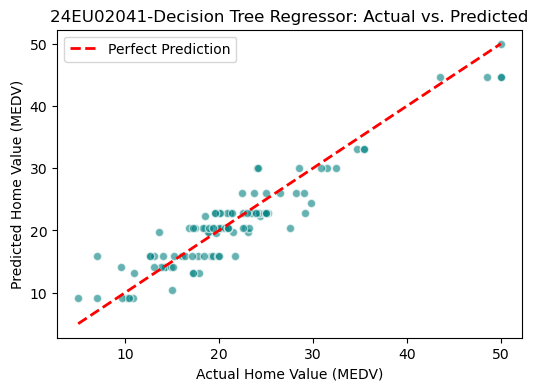

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test_r, reg_preds, color='teal', alpha=0.6, edgecolor='white')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("24EU02041-Decision Tree Regressor: Actual vs. Predicted")
plt.xlabel("Actual Home Value (MEDV)")
plt.ylabel("Predicted Home Value (MEDV)")
plt.legend()
plt.show()


TASK 2.1

In [ ]:
import warnings

In [ ]:
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [ ]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [ ]:
sonar_columns = sonar_features + ['Class']

In [ ]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [ ]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [ ]:
X_sonar = sonar_df[sonar_features]

In [ ]:
y_sonar = sonar_df['Class_numeric']

In [ ]:
scaler_sonar = StandardScaler()

In [ ]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [ ]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

In [ ]:
print("Sonar Training Set Shape:", X_train_s.shape)

Sonar Training Set Shape: (145, 60)


In [ ]:
print("Sonar Test Set Shape:", X_test_s.shape)

Sonar Test Set Shape: (63, 60)


TASK - 2.2

In [ ]:
from sklearn.ensemble import BaggingClassifier

In [ ]:
from sklearn.metrics import accuracy_score


In [ ]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
bagging_model.fit(X_train_s, y_train_s)


BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=50, n_jobs=-1, random_state=42)

In [ ]:
bagging_preds = bagging_model.predict(X_test_s)

In [ ]:
bagging_accuracy = accuracy_score(y_test_s, bagging_preds)

In [ ]:
print(f"Bagging Classifier Test Accuracy: {bagging_accuracy * 100:.2f}%")

Bagging Classifier Test Accuracy: 80.95%


TASK - 2.3

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [ ]:
rf_model.fit(X_train_s, y_train_s)


RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
rf_preds = rf_model.predict(X_test_s)

In [ ]:
rf_accuracy = accuracy_score(y_test_s, rf_preds)

In [ ]:
print(f"Random Forest Classifier Test Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Classifier Test Accuracy: 82.54%


TASK - 2.4

In [ ]:
from sklearn.ensemble import VotingClassifier

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.svm import SVC

estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

In [ ]:
voting_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

In [ ]:
voting_model.fit(X_train_s, y_train_s)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=500,
                                                 random_state=42)),
                             ('dt',
                              DecisionTreeClassifier(max_depth=5,
                                                     random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 n_jobs=-1, voting='soft')

In [ ]:
voting_preds = voting_model.predict(X_test_s)

In [ ]:
voting_accuracy = accuracy_score(y_test_s, voting_preds)

In [ ]:

print(f"Voting Classifier Test Accuracy: {voting_accuracy * 100:.2f}%")

Voting Classifier Test Accuracy: 87.30%


TASK - 2.5

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:
ensemble_results = pd.DataFrame({
    'Ensemble Technique': ['Bagging (DT Base)', 'Random Forest', 'Voting Classifier (Soft)'],
    'Test Accuracy (%)': [bagging_accuracy * 100, rf_accuracy * 100, voting_accuracy * 100]
})

In [ ]:

print("--- Performance Comparison ---")

--- Performance Comparison ---


In [ ]:
print(ensemble_results.to_string(index=False))

      Ensemble Technique  Test Accuracy (%)
       Bagging (DT Base)          80.952381
           Random Forest          82.539683
Voting Classifier (Soft)          87.301587


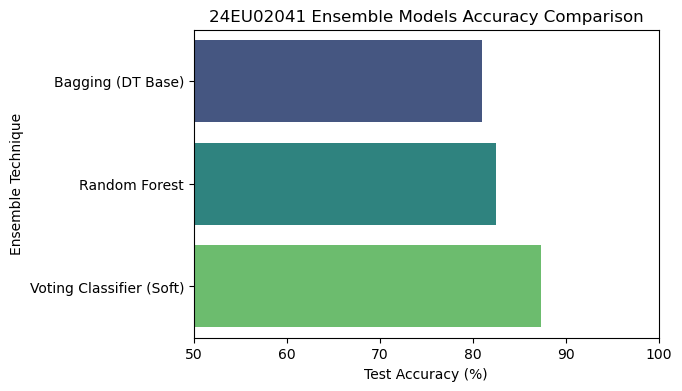

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=ensemble_results, x='Test Accuracy (%)', y='Ensemble Technique', palette='viridis')
plt.xlim([50, 100])
plt.title("24EU02041 Ensemble Models Accuracy Comparison")
plt.show()


TASK - 3.1

In [ ]:
import warnings

In [ ]:
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)

In [ ]:
adaboost_model.fit(X_train_s, y_train_s)

AdaBoostClassifier(random_state=42)

In [ ]:
ada_preds = adaboost_model.predict(X_test_s)

In [ ]:
ada_accuracy = accuracy_score(y_test_s, ada_preds)

In [ ]:
print(f"AdaBoost Classifier Test Accuracy: {ada_accuracy * 100:.2f}%")

AdaBoost Classifier Test Accuracy: 82.54%


TASK - 3.2

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

In [ ]:
gb_model.fit(X_train_s, y_train_s)

GradientBoostingClassifier(random_state=42)

In [ ]:
gb_preds = gb_model.predict(X_test_s)

In [ ]:
gb_accuracy = accuracy_score(y_test_s, gb_preds)

In [ ]:
print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy * 100:.2f}%")

Gradient Boosting Classifier Test Accuracy: 79.37%


TASK - 3.3

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5]
}

In [ ]:
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

In [ ]:
grid_gb.fit(X_train_s, y_train_s)

GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [ ]:
best_gb = grid_gb.best_estimator_

In [ ]:
tuned_gb_preds = best_gb.predict(X_test_s)

In [ ]:
tuned_gb_accuracy = accuracy_score(y_test_s, tuned_gb_preds)

In [ ]:
print("Optimal Hyperparameters Selected:", grid_search_params := grid_gb.best_params_)

Optimal Hyperparameters Selected: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}


In [ ]:
print(f"Tuned Gradient Boosting Test Accuracy: {tuned_gb_accuracy * 100:.2f}%")

Tuned Gradient Boosting Test Accuracy: 74.60%


TASK  - 3.4

In [ ]:
master_comparison = pd.DataFrame({
    'Model Classifier': [
        'Bagging Classifier',
        'Random Forest Classifier',
        'Voting Ensemble (Soft)',
        'AdaBoost Classifier',
        'Base Gradient Boosting',
        'Tuned Gradient Boosting'
    ],
    'Accuracy (%)': [
        bagging_accuracy * 100,
        rf_accuracy * 100,
        voting_accuracy * 100,
        ada_accuracy * 100,
        gb_accuracy * 100,
        tuned_gb_accuracy * 100
    ]
}).sort_values(by='Accuracy (%)', ascending=False)


In [ ]:

print("--- Master Performance Table: Tasks 2 & 3 ---")


--- Master Performance Table: Tasks 2 & 3 ---


In [ ]:
print(master_comparison.to_string(index=False))

        Model Classifier  Accuracy (%)
  Voting Ensemble (Soft)     87.301587
Random Forest Classifier     82.539683
     AdaBoost Classifier     82.539683
      Bagging Classifier     80.952381
  Base Gradient Boosting     79.365079
 Tuned Gradient Boosting     74.603175


TASK - 3.5

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import numpy as np

In [ ]:
rf_importances = rf_model.feature_importances_

In [ ]:
gb_importances = best_gb.feature_importances_

In [ ]:
top_indices_rf = np.argsort(rf_importances)[-10:]

In [ ]:
top_indices_gb = np.argsort(gb_importances)[-10:]

In [ ]:
features_list = [f"F_{i}" for i in range(1, 61)]

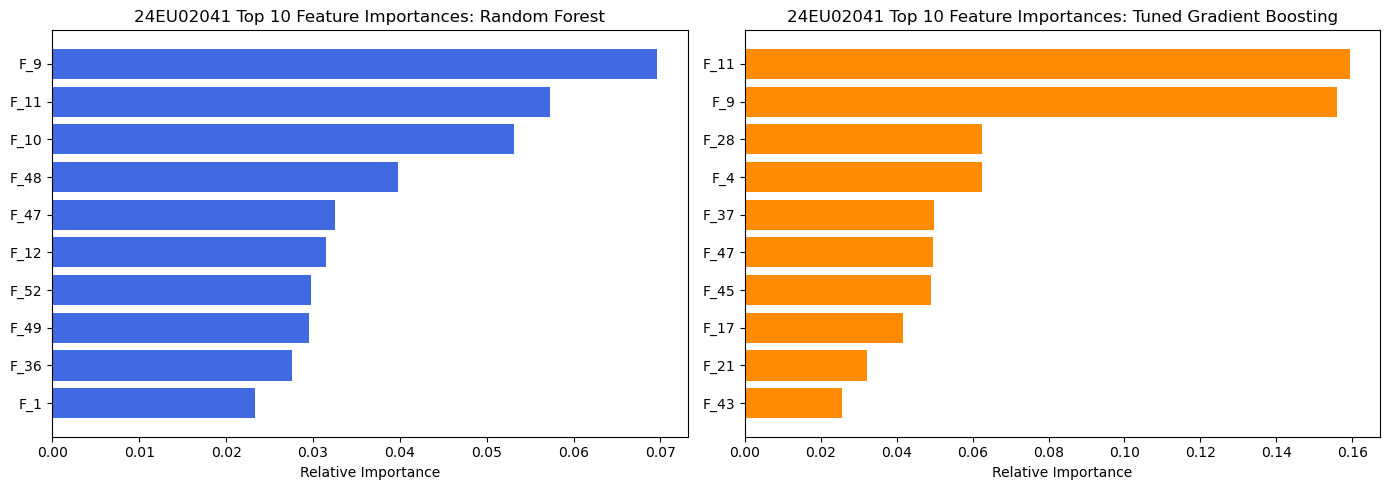

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(range(10), rf_importances[top_indices_rf], color='royalblue', align='center')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([features_list[i] for i in top_indices_rf])
axes[0].set_title("24EU02041 Top 10 Feature Importances: Random Forest")
axes[0].set_xlabel("Relative Importance")

# Plot Tuned Gradient Boosting Importances
axes[1].barh(range(10), gb_importances[top_indices_gb], color='darkorange', align='center')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([features_list[i] for i in top_indices_gb])
axes[1].set_title("24EU02041 Top 10 Feature Importances: Tuned Gradient Boosting")
axes[1].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()

POST LAB TASK - 1

Accuracy: 0.7654

Confusion Matrix:
[[82 23]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.78      0.80       105
           1       0.71      0.74      0.72        74

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



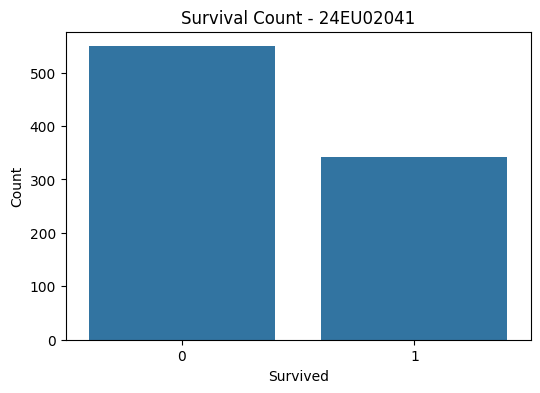

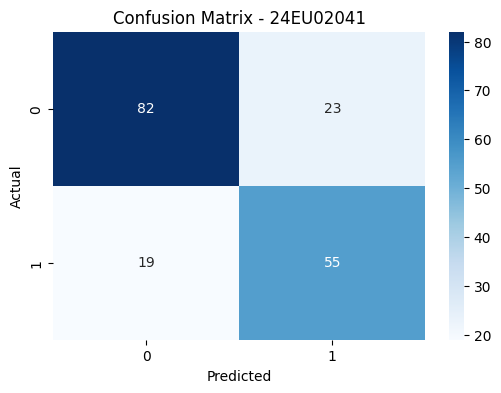

In [2]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset
titanic = sns.load_dataset('titanic')

# Select useful columns and create a copy
data = titanic[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']].copy()

# Handle Missing Values
data['age'] = data['age'].fillna(data['age'].median())
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])

# Convert Categorical Data into Numerical
encoder = LabelEncoder()

data['sex'] = encoder.fit_transform(data['sex'])
data['embarked'] = encoder.fit_transform(data['embarked'])

# Features and Target
X = data.drop('survived', axis=1)
y = data['survived']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Decision Tree Classifier
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ---------------- Graph 1 ----------------
plt.figure(figsize=(6,4))
sns.countplot(x='survived', data=data)
plt.title("Survival Count - 24EU02041")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

# ---------------- Graph 2 ----------------
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - 24EU02041")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

POST LAB TASK - 2

Mean Absolute Error: 0.533
Mean Squared Error: 0.556
Root Mean Squared Error: 0.746
R2 Score: 0.576


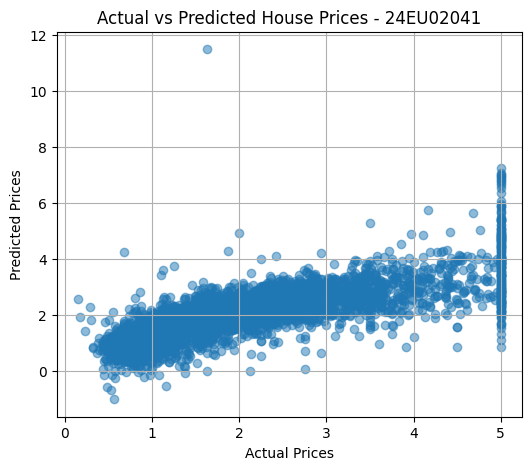

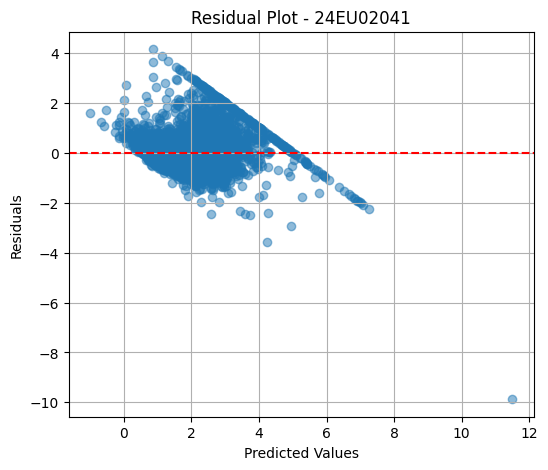

In [3]:
# Import Libraries
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset
housing = fetch_california_housing()

X = housing.data
y = housing.target

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 3))
print("Mean Squared Error:", round(mse, 3))
print("Root Mean Squared Error:", round(rmse, 3))
print("R2 Score:", round(r2, 3))

# ---------------- Graph 1 ----------------
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices - 24EU02041")
plt.grid(True)
plt.show()

# ---------------- Graph 2 ----------------
plt.figure(figsize=(6,5))
plt.scatter(y_pred, y_test - y_pred, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - 24EU02041")
plt.grid(True)
plt.show()